### **Treći domaći zadatak**

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind, norm

Data su dva skupa podataka, jedan sa $m$ merenja, i drugi sa $n$ merenja. Prvi skup se odnosi na gustine fluksa merene u slučajnim pozicijama na nebu a drugi na gustine fluksa merene u pozicijama specifičnih grupa galaksija (gustina fluksa je $S [mJy]$).

#### **Prvi zadatak**

Podaci su u obliku histograma. Rekonstruisati _sirove uzorke_ i objasniti zašto je ovaj korak neophodan (može se koristiti _np.repeat_). Iscrtati pripadajuće histograme.

In [22]:
#Ovime uvozimo datoteku datu u formi tabele sa tri vrste, vrednost fluksa, br galaksija, br slučajnih pozicija
ks_uzorci = np.genfromtxt('gr.dat', skip_header = 2, skip_footer=2)

#Ovde se ta "tabela" transponuje tako da vrste postaju redovi, imamo samo tri niza ovako sa svim odgovarajućim vrednostima, mJy, G, R 
mJy, G, R = ks_uzorci.T

#Sada se iz histograma očita koliko puta je neka vrednost mJy ponovljena za uzorak galaksije/slučajan uzorak
#Ova vrednost se ponovi u sirovom uzorku toliko puta a funkcija astype pretvara broj iz G/R kolone u ceo broj jer se ne može neka vrednost ponoviti 0.n puta  
G_pre = np.repeat(mJy, G.astype(int))
R_pre = np.repeat(mJy, R.astype(int))

#Poverava se da li je i nakon rekonstrukcije isti broj elemenata kao pre, zbog dodavanja uslova za ceo broj
#Kada se otvori fajl može se primetiti da je na dnu kolona za G = 386, za R = 290  
print(len(G_pre), len(R_pre))

386 290


Pošto su podaci dati u obliku učestalosti po binovima, potrebno je odrediti i koja bi bila pojedinačna merenja gustine fluksa. Ovo služi da bi mogle da se primene neke od metoda statističke obrade koje uzimaju uzorke pojedinačnih vrednosti, odnosno koriste empirijsku raspodelu podataka.

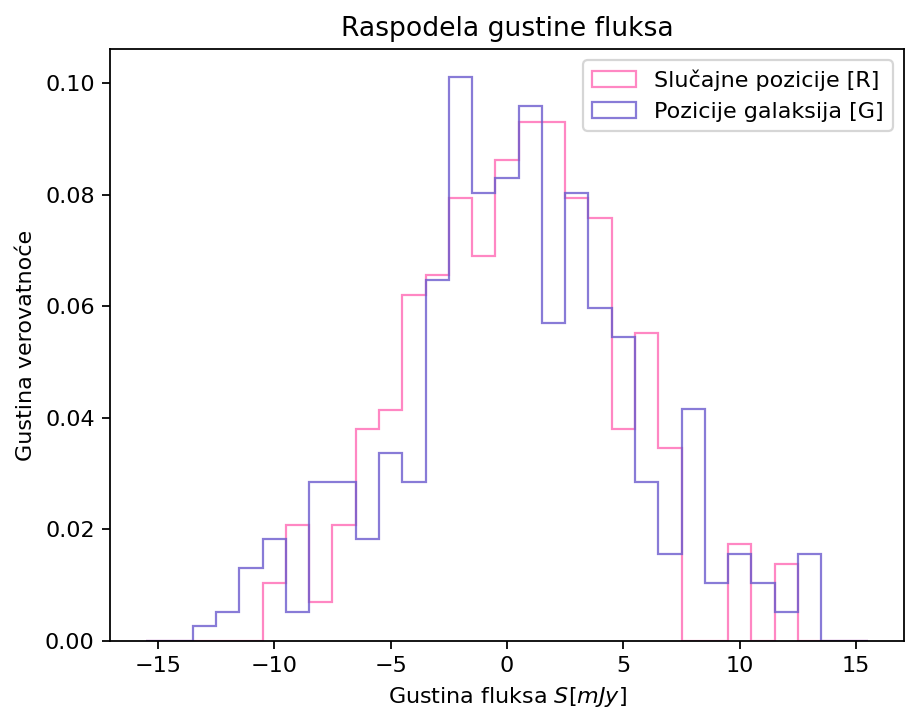

In [35]:
#Potreban je isti broj binova kao što je bilo u histogramu od kojeg su podaci rekonstruisani
broj = len(mJy)

#Širina jednog bina iz originalnih podataka
dm = mJy[1] - mJy[0]

#Iscrtavanje histograma za sirove podatke, različit je broj vrednosti za oba skupa pa se poredi gustina verovatnoće
plt.figure(dpi = 160)
plt.hist(R_pre, 
         bins=broj, 
         #gde histogram počinje i završava se, prvoj vrednosti koja predstavlja centar bina se oduzima polovina širine (analogno za poslednju)
         #i onda u tom intervalu se vrednosti dele na broj originalnih binova 
         range=(mJy[0] - dm/2, mJy[-1] + dm/2), 
         histtype='step', 
         alpha=0.8, 
         density = 'True', 
         color='hotpink', 
         label='Slučajne pozicije [R]')

plt.hist(G_pre, 
         bins=broj,
         range=(mJy[0] - dm/2, mJy[-1] + dm/2), 
         histtype='step', 
         alpha=0.8, 
         density = 'True', 
         color='slateblue', 
         label='Pozicije galaksija [G]')

plt.title('Raspodela gustine fluksa')
plt.xlabel(r'Gustina fluksa $S [mJy]$')
plt.ylabel('Gustina verovatnoće')
plt.legend()
plt.show()

#### **Drugi zadatak**

Koristeći se Kolmogorov-Smirnov dvouzoračkim testom, treba ispitati hipotezu _da postoji eksces gustine fluksa na ne-slučajnim pozicijama_. Dodatno proveriti hipotezu koristeći se U-testom. Interpretirati.

In [36]:
#Kolmogorov-Smirnov dvouzorački test
#porede se kumulativne raspodele i da li je za G manja od R ('less')
#sam pronalazi gde je najveća razlika kumulativnih raspodela za više vrednosti praga fluksa S za koje ih računa
ks_rez = ks_2samp(G_pre, R_pre, alternative='less')

#U-test
#ako se uzmu nasumično vrednosti iz uzorka G da li će češće biti veća od vrednosti u R ('greater')
u_rez = mannwhitneyu(G_pre, R_pre, alternative='greater')

print('KS test')
print(np.round(ks_rez, 4))

print('U-test')
print(np.round(u_rez, 4))


KS test
[0.0674 0.2099]
U-test
[5.66135e+04 3.98800e-01]


Postavljeno je pitanje - da li su gustine fluksa veće na pozicijama galaksija nego na slučajnim pozicijama? Odnosno, nulta hipoteza **$H_{0}$** je **da ne postoji statistički značajan excess gustine fluksa na pozicijama galaksija**. To se, kod dva nova uzorka, gleda da li su sirove vrednosti $G$ pomerene ka većim u odnosu na $R$. <br><br>

_KS test_ : $$H_0: \quad F_G(S) = F_R(S)$$

Dobijeno je da je najveća razlika između kumulativnih raspodela za $G$ i $R$ jednaka $6.7\%$. 

Za **p-vrednost**, koja predstavlja verovatnoću da se, ako je nulta hipoteza tačna, ponovi rezultat, dobijeno je $0.21$. To je za vrednost $0.05$ koja je potrebna da se hipoteza odbaci, dosta značajnije. <br>

_U-test_:  $$H_0: \quad G_{\text{sirovo}} \text{ i } R_{\text{sirovo}} \text{ potiču iz iste raspodele} $$

Za p-vrednost dobijeno je $0.40$ što je, ponovo, veće od vrednosti potrebne za odbacivanje hipoteze. <br><br>

_Zaključak_:

 $H_0$ se ne može odbaciti, odnosno, **ne postoji višak gustine fluksa na ne-slučajnim pozicijama**.

#### **Treći zadatak**

Generisati dva skupa od po $n = 10$ posmatranja: jedan iz raspodele $\mathcal{N}(0, 1)$, drugi iz mešavine $(1 - \epsilon) \mathcal{N}(0,1) + \epsilon \mathcal{N}(0, 3)$ i primeniti _t-test_ na njih, proveravajući da li se $H_0 : \mu_1 = \mu_2$ odbacuje na nivou značajnosti $\alpha = 0.05$.

Ovaj postupak (generisanje + t-test) ponoviti 1000 puta za svaku od 20 vrednosti $\epsilon \in [0, 0.5]$  izračunati udeo slučajeva u kojima se $H_0$ odbacuje za svako $\epsilon$. Prikazati zavisnost ovog udela od $\epsilon$. 

Zatim ponoviti čitav postupak promenom srednje vrednosti _uže_ normalne raspodele na $\mu = 0.5$.

In [54]:
np.random.seed(0)

#Broj posmatranja, ponavljanja za svaku od vrednosti u skupu za epsilon i nivo znacajnosti zadati u zadatku
n = 10
N = 1000
alfa = 0.05

#Skup vrednosti za koji se pravi promena u široj raspodeli
epsilon = np.linspace(0, 0.5, 20)

#Uzorak iz uže ili šire mešavine za dve normalne raspodele koje će biti određene doprinosom epsilon
def uzorak_mesavina(eps, mu=0, n=10):
    #Ovde se uzima 10 slučajnih brojeva između 0 i 1 
    izbor = np.random.uniform(0, 1, n)
    
    #U drugom skupu se može vrednost izabrati sa verovatnoćom 1-eps za normalnu raspodelu(0, 1)
    # i sa verovatnoćom eps za (0, 3) i za svaku od 10 tačaka se pravi taj izbor
    #Zato pre poređenja pravimo skup sa istim brojem elemenata
    x = np.zeros(n)
    

    #Ako je broj generisan iz 10 slučajnih između 1 i 0 veći ili jednak od eps onda se uzima vrednost iz uže raspodele
    #Zato što je kod šire raspodele, u intervalu od 0 do epsilon, duzina intervala epsilon, 
    #tako da ako se uzme broj iz intervala npr [0, 0.2) biće 20% celog pa je verovatoća da će upasti isto 20%
    #Svi ostali slučajevi prepisaće se 1-eps delu 
    x[izbor >= eps] = norm.rvs(mu, 1, size=np.sum(izbor >= eps))
    
    #Broj manji od eps, uzima se vrednost iz šire raspodele
    x[izbor < eps] = norm.rvs(0, 3, size=np.sum(izbor < eps))
    
    return x

In [55]:
#Ovde će se definisati funkcija koja za različite srednje vrednosti vrši t-test
def simulacija(mu_mesavine):
    udeli = []
    
    for eps in epsilon:
        #Pravi se brojač da se za svako eps utvrdi broj odbačenih H0 mu1=mu2
        broj_odbacivanja = 0
        
        #Za svaku vrednost epsilon će se uraditi 1000 t-testova
        for i in range(N):
            #Prvi uzorak iz normalne raspodele N(0, 1), 10 elemenata
            x1 = norm.rvs(0, 1, size=n)
            
            #Drugi uzorak iz mešavine raspodela, 10 elemenata
            x2 = uzorak_mesavina(eps, mu=mu_mesavine, n=n)
            
            #T-test za dva nezavisna uzorka, da li oba potiču iz populacije sa istom sr vrednosti
            rezultat = ttest_ind(x1, x2)
            
            #kao u prošlom zadatku gleda se p-vr < alfa za odbacivanje
            if rezultat.pvalue < alfa:
                broj_odbacivanja += 1
        
        #koji je udeo u 1000 izvršenih testova onih odbačenih
        udeli.append(broj_odbacivanja / N)
    
    return np.array(udeli)

In [48]:
#1. slucaj
udeo_mu0 = simulacija(mu_mesavine=0)

In [49]:
#2. slucaj
udeo_mu05 = simulacija(mu_mesavine=0.5)

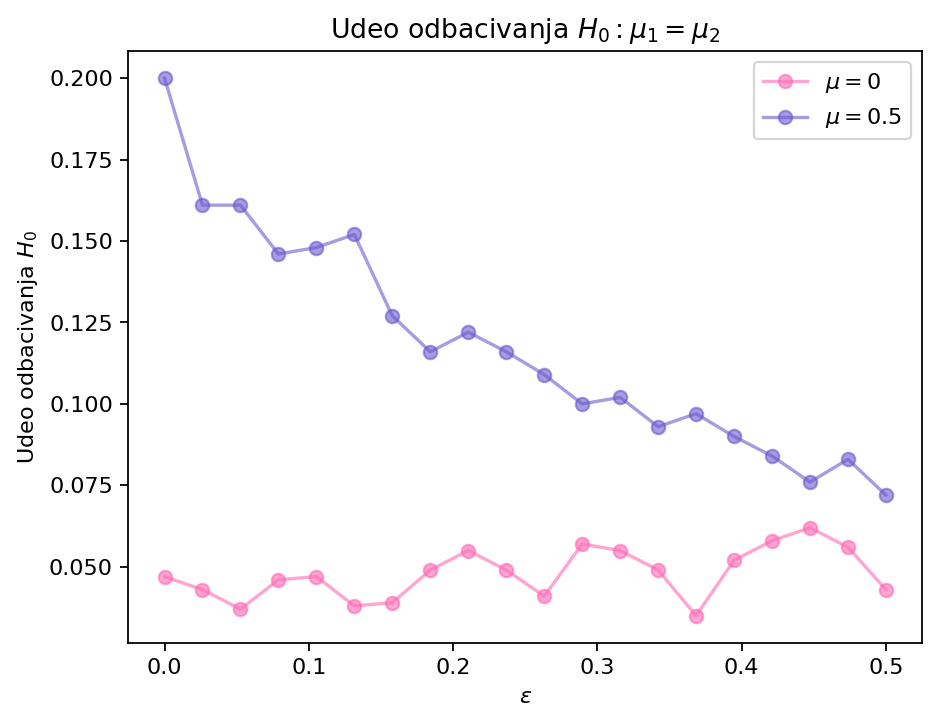

In [57]:
plt.figure(dpi = 160)

plt.plot(epsilon, udeo_mu0, color = 'hotpink', alpha=0.6, marker='o', label=r'$\mu = 0$')
plt.plot(epsilon, udeo_mu05, color = 'slateblue', alpha=0.6, marker='o', label=r'$\mu = 0.5$')

#plt.axhline(alfa, linestyle='--', color='gray', label=r'$\alpha = 0.05$') ne treba?

plt.xlabel(r'$\epsilon$')
plt.ylabel(r'Udeo odbacivanja $H_0$')
plt.title(r'Udeo odbacivanja $H_0: \mu_1 = \mu_2$')
plt.legend()

plt.show()

Porede se srednje vrednosti dva uzorka gde je jedan generisan iz uobičajene normalne raspodele $\mathcal{N}(0, 1)$ a drugi iz neke mešavine koja predstavlja takođe uobičajenu populaciju ali i deo prepisan nekoj "kontaminaciji" i količina odstupanja data je kroz odnos $(1 - \epsilon)\mathcal{N}(0, 1) + \epsilon \mathcal{N}(0, 3)$. Dva slučaja se odnose na promenu srednje vrednosti normalne raspodele udesno oko vrednosti $0.5$ što ulazi u obe populacije.

Na grafiku je sa roze prikazana $\mu = 0$ a sa ljubičastom $\mu = 0.5$. Prvu vidimo da osciluje oko vrednosti $0.05$ a druga se sa povećanjem vrednosti epsilon približava vrednosti $0.05$. Razlog tome jeste što je prvi uzorak uvek $\mathcal{N}(0, 1)$ a drugi je za $\epsilon = 0$ samo $\mathcal{N}(0.5, 1)$ pa se srednje vrednosti razlikuju i nulta hipoteza je češće odbačena. Za sve veće $\epsilon$ zbog $\mu_2 = 0.5(1-\epsilon)$ vrednost se približava $0$ i nulta hipoteza se manje odbacuje. Kod slučaja za $\mu = 0$ može se primetiti i da sa povećanjem $\epsilon$ oscilovanje oko vrednosti $0.05$ postaje veće jer doprinos u mešavini koja dolazi iz šire raspodele raste pa se mogu u 10 uzoraka naći i ekstremnije vrednosti.